Index 0: malignant (The 'Positive' case for cancer)
Index 1: benign (The 'Negative' case for cancer)
target
1    357
0    212
Name: count, dtype: int64
target
0    978.376415
1    462.790196
Name: mean area, dtype: float64
Training set size: 455 patients.
Test set size: 114 patients
New Mean of first feature: -0.00
New Std of first feature: 1.00


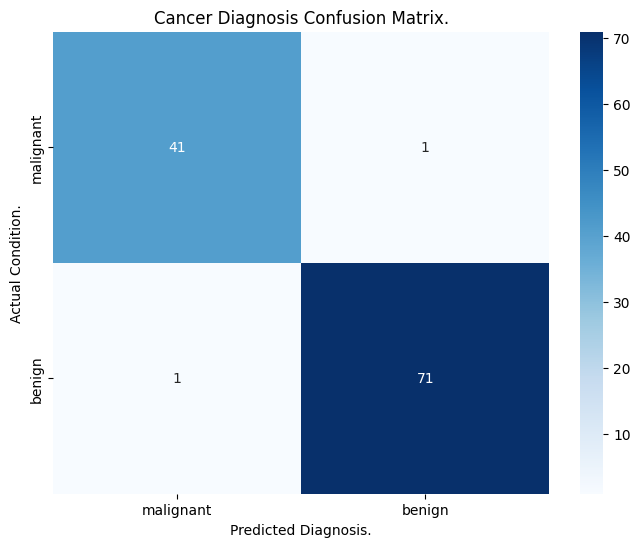

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



<Figure size 640x480 with 0 Axes>

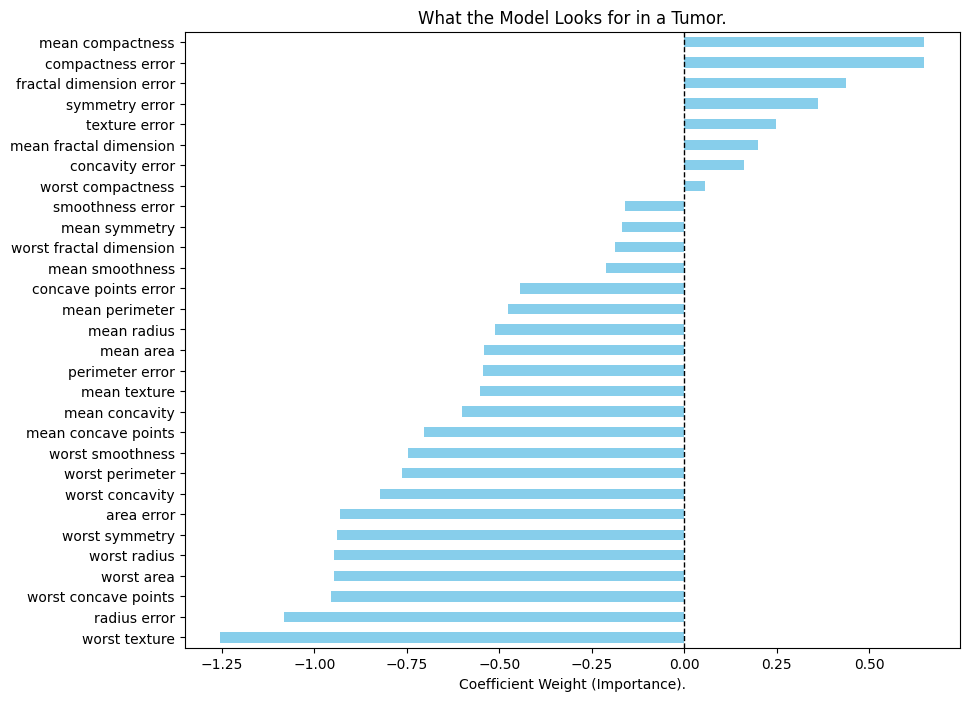

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

#load the data
raw_data = load_breast_cancer()

#create dataframe
df = pd.DataFrame(raw_data.data, columns = raw_data.feature_names)
df.head()

#add the target from raw data, where 0 is cancerous and 1 is malignant
df['target'] = raw_data.target

#who is in our dataset?
print(f"Index 0: {raw_data.target_names[0]} (The 'Positive' case for cancer)")
print(f"Index 1: {raw_data.target_names[1]} (The 'Negative' case for cancer)")
print(df['target'].value_counts())

#physical size difference, 1 v. 0
print(df.groupby('target')['mean area'].mean())

from sklearn.model_selection import train_test_split
#separate features(x) from target(y)
x = df.drop('target', axis = 1) #all columns but the answer
y = df['target'] #just the answer

#train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2,
    random_state=42,
    stratify=y #such that both piles have same % of cancer
)

print(f'Training set size: {x_train.shape[0]} patients.')
print(f'Test set size: {x_test.shape[0]} patients')

#standardise to adjust for difference in scales, e.g: Mean area = 1000s while smoothness = 0.1s
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# 'Fit' calculates the mean and std; 'Transform' applies the math
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"New Mean of first feature: {x_train_scaled[:,0].mean():.2f}")
print(f"New Std of first feature: {x_train_scaled[:,0].std():.2f}")

from sklearn.linear_model import LogisticRegression
#initialise model
model = LogisticRegression()

#train the model
model.fit(x_train_scaled, y_train)

#predictions
y_pred = model.predict(x_test_scaled)

#Let's evaluate!
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

#calculate the CM
cm = confusion_matrix(y_test, y_pred)

#visualise it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=raw_data.target_names,
            yticklabels=raw_data.target_names)
plt.xlabel('Predicted Diagnosis.')
plt.ylabel('Actual Condition.')
plt.title('Cancer Diagnosis Confusion Matrix.')
plt.show()
plt.savefig('Cancer Diagnosis Confusion Matrix.png')

#print the detailed report 
print(classification_report(y_test, y_pred, target_names=raw_data.target_names))

#get coefficients from the model
importance = pd.Series(model.coef_[0], index = raw_data.feature_names)
#sort them by magnitude
importance_sorted = importance.sort_values()

#top 10 most influential features
plt.figure(figsize=(10, 8))
importance_sorted.plot(kind='barh', color='skyblue')
plt.title("What the Model Looks for in a Tumor.")
plt.xlabel("Coefficient Weight (Importance).")
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.show()